In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import random
#Setting a random seed to ensure experiments are reproducible
seed=42
# 1. Python random
random.seed(seed)

# 2. NumPy
np.random.seed(seed)

# 3. PyTorch (CPU)
torch.manual_seed(seed)

# 4. PyTorch (GPU)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# 5. Deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def createJobsTensorDataset(data_dir):
    #creates a Tensor from the Jobs Dataset given the directory of the .npz files
    npz =np.load(data_dir)
    X_tensor= torch.tensor(npz["x"][:,:,0], dtype=torch.float32) #takes the 0th slice of the replications
    y_tensor= torch.tensor(npz["yf"][:,0], dtype=torch.float32)
    t_tensor= torch.tensor(npz["t"][:,0], dtype=torch.float32)
    return TensorDataset(X_tensor,t_tensor,y_tensor)

jobs_train= createJobsTensorDataset("C:\\Users\\evany\\Desktop\\MaLabRotation\\Data\\FredJoData\\jobs_DW_bin.new.10.train.npz")
jobs_test= createJobsTensorDataset("C:\\Users\\evany\\Desktop\\MaLabRotation\\Data\\FredJoData\\jobs_DW_bin.new.10.test.npz")

train_loader = DataLoader(jobs_train, batch_size=64, shuffle=True)
test_loader = DataLoader(jobs_test, batch_size=64, shuffle=False)

Shape: torch.Size([2570, 17])
Mean: tensor([-0.0024,  0.0151,  0.3673,  0.0490,  0.7136,  0.4039,  0.0112,  0.0177,
        -0.0035, -0.0045,  0.0160,  0.0086,  0.0143,  0.1669,  0.1658,  0.0129,
         0.0101])
Std: tensor([0.9957, 1.0028, 0.4822, 0.2160, 0.4522, 0.4908, 1.0049, 1.0110, 0.9944,
        0.9936, 1.0030, 1.0187, 1.0428, 0.3730, 0.3719, 1.0055, 0.1001])
Min: tensor([-1.4611, -3.9868,  0.0000,  0.0000,  0.0000,  0.0000, -1.1474, -1.1105,
        -1.1640, -0.9488, -2.1440, -0.5581, -0.5188,  0.0000,  0.0000, -0.9800,
         0.0000])
Max: tensor([ 2.1143,  1.8054,  1.0000,  1.0000,  1.0000,  1.0000,  8.7520, 10.1651,
         2.4467,  2.7733,  2.1137, 23.0528, 29.0226,  1.0000,  1.0000,  7.1360,
         1.0000])


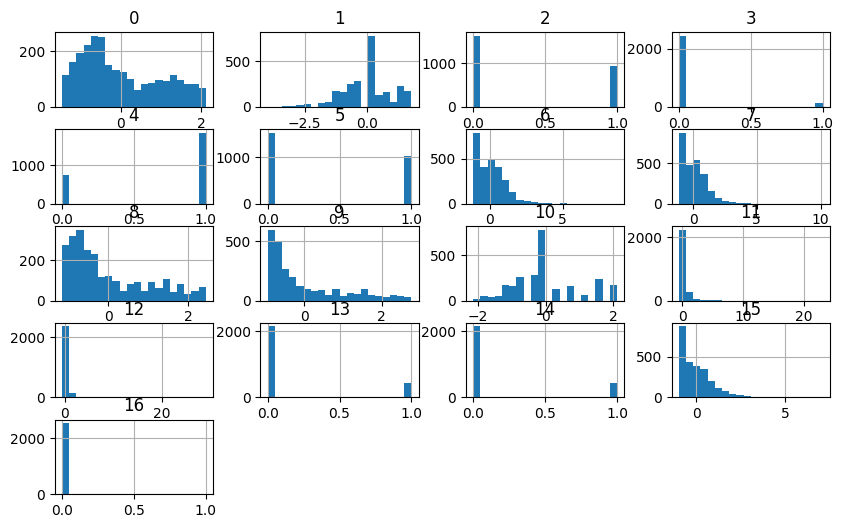

In [2]:
#Exploring the covariates X of the Jobs Dataset
def explore_tensor(X):
    print("Shape:", X.shape)
    print("Mean:", X.mean(dim=0))
    print("Std:", X.std(dim=0))
    print("Min:", X.min(dim=0).values)
    print("Max:", X.max(dim=0).values)

    import pandas as pd
    import matplotlib.pyplot as plt
    
    df = pd.DataFrame(X.numpy())
    df.hist(figsize=(10,6), bins=20)
    plt.show()

X_tensor = jobs_train.tensors[0]
explore_tensor(X_tensor)

Shape: torch.Size([2570])
Mean: tensor(0.8529)
Std: tensor(0.3543)
Min: tensor(0.)
Max: tensor(1.)


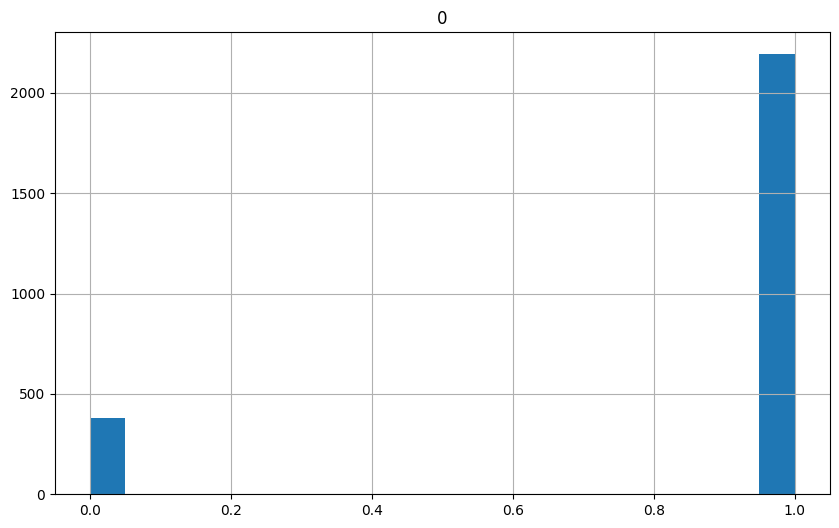

In [15]:
Y_tensor = jobs_train.tensors[2]
explore_tensor(Y_tensor)

In [5]:
#AutoEncoder: an Encoder paired with a Decoder to ensure x => z => x_recon is close
#Encoder: multi-layer feedforward network 
#Turns covariates X => representation Z

class AutoEncoder(nn.Module):
    def __init__(self,input_dim,hidden_dim,latent_dim):#,binary_index,cont_index
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # Hidden layer 1
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2), #Hidden Layer 2
            nn.ReLU(),
            nn.Linear(hidden_dim//2,latent_dim)
        )
        #Output heads
        #Reconstruction head via decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2), # Hidden layer 1
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim), #Hidden Layer 2
            nn.ReLU(),
            nn.Linear(hidden_dim,input_dim)
        )


        #prospensity_head
        self.propensity_head= nn.Linear(latent_dim,1)

        #pseudo-outcome head, T=0, predicts a biased outcome estimation Y0
        self.t0_head =nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,1)
        )
        #pseudo-outcome head, T=1, predicts a biased outcome estimation Y1
        self.t1_head=nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,1)
        )

        
    def forward(self,x):
        z = self.encoder(x) #representation Z

        
        t_logit = self.propensity_head(z)
        x_recon = self.decoder(z)

        #pseudooutcomes
        y0_pseudo=self.t0_head(z)
        y1_pseudo=self.t1_head(z)
        return {
            "x_recon" :x_recon,
            "t_logit" :t_logit,
            "y0_pseudo":y0_pseudo,
            "y1_pseudo":y1_pseudo
        }





In [19]:
def pseudo_outcome_loss(y0_hat, y1_hat, t_batch, y_batch, outcome_type="continuous"):
    """
    Trains only the factual branch:
      - if t=0, compare y0_hat to y
      - if t=1, compare y1_hat to y
    """

    t_batch = t_batch.float()
    y_batch = y_batch.float()


    if outcome_type == "continuous":
        loss_fn = nn.MSELoss(reduction="none")
    elif outcome_type == "binary":
        loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    else:
        raise ValueError("outcome_type must be 'continuous' or 'binary'")

    loss0 = loss_fn(y0_hat, y_batch)   # [B, 1]
    loss1 = loss_fn(y1_hat, y_batch)   # [B, 1]

    masked_loss = (1 - t_batch) * loss0 + t_batch * loss1
    return masked_loss.mean()

In [6]:


def pseudo_outcome_loss(
    y0_hat, 
    y1_hat, 
    t_batch, 
    y_batch, 
    binary_idx, 
    cont_idx
):
    """
    Mixed-type masked factual loss:
      - BCEWithLogitsLoss for binary variables
      - MSELoss for continuous variables
      - Only factual branch contributes (masking by treatment)

    Inputs:
      y0_hat: [B, D]
      y1_hat: [B, D]
      t_batch: [B, 1]
      y_batch: [B, D]
      binary_idx: list of indices for binary vars
      cont_idx: list of indices for continuous vars
    """

    t_batch = t_batch.float()
    y_batch = y_batch.float()

    total_loss = 0.0
    total_count = 0

    # Define loss functions
    bce = nn.BCEWithLogitsLoss(reduction="none")
    mse = nn.MSELoss(reduction="none")

    # --- Binary variables ---
    if len(binary_idx) > 0:
        y0_bin = y0_hat[:, binary_idx]
        y1_bin = y1_hat[:, binary_idx]
        y_bin = y_batch[:, binary_idx]

        loss0_bin = bce(y0_bin, y_bin)
        loss1_bin = bce(y1_bin, y_bin)

        masked_bin = (1 - t_batch) * loss0_bin + t_batch * loss1_bin

        total_loss += masked_bin.sum()
        total_count += y_bin.numel()

    # --- Continuous variables ---
    if len(cont_idx) > 0:
        y0_cont = y0_hat[:, cont_idx]
        y1_cont = y1_hat[:, cont_idx]
        y_cont = y_batch[:, cont_idx]

        loss0_cont = mse(y0_cont, y_cont)
        loss1_cont = mse(y1_cont, y_cont)

        masked_cont = (1 - t_batch) * loss0_cont + t_batch * loss1_cont

        total_loss += masked_cont.sum()
        total_count += y_cont.numel()

    # Normalize to per-element average
    if total_count > 0:
        return total_loss/total_count
    else:
        return torch.tensor(0.0, device=y_batch.device)

In [20]:
#Training Functions
def detect_binary_continuous_columns(X_tensor, tol=1e-6):
    """
    Detect binary vs continuous columns automatically.

    A column is considered binary if its unique values are only {0,1}
    within numerical tolerance

    Returns index of continuous and binary columns
    """
    binary_idx = []
    continuous_idx = []

    n_features = X_tensor.shape[1]

    for i in range(n_features):
        col = X_tensor[:, i]
        unique_vals = torch.unique(col)

        # Round tiny numerical noise
        unique_vals = torch.round(unique_vals / tol) * tol

        # Check whether all unique values are 0 or 1
        is_binary = torch.all((unique_vals == 0) | (unique_vals == 1)).item()

        if is_binary:
            binary_idx.append(i)
        else:
            continuous_idx.append(i)

    return binary_idx, continuous_idx

def train_mixed_autoencoder(
    dataset,
    hidden_dim=8,
    latent_dim=4,
    batch_size=64,
    lr=1e-3,
    num_epochs=50,
    verbose=True,
    device=None
):
    """
    Train an autoencoder on a TensorDataset(X, t, y) or TensorDataset(X).

    Automatically detects binary and continuous columns in X and uses:
      - BCEWithLogitsLoss for binary columns
      - MSELoss for continuous columns

    Returns:
      model, history, binary_idx, continuous_idx
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Extract X_tensor from TensorDataset
    if not hasattr(dataset, "tensors"):
        raise ValueError("dataset must be a TensorDataset")

    X_tensor = dataset.tensors[0].float()

    # Detect column types
    binary_idx, continuous_idx = detect_binary_continuous_columns(X_tensor)

    if verbose:
        print("Detected binary columns:", binary_idx)
        print("Detected continuous columns:", continuous_idx)

    input_dim = X_tensor.shape[1]
    model = AutoEncoder(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)

    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss()
    prop= nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_cont_loss = 0.0
        epoch_bin_loss = 0.0
        epoch_prop_loss =0.0
        epoch_pseudo_loss =0.0

        for X_batch,T_batch,Y_batch in loader:
            X_batch = X_batch.float().to(device)
            T_batch = T_batch.float().to(device)
            Y_batch = Y_batch.float().to(device)
            outputs = model(X_batch)
            #print("X_batch:", X_batch.shape)
            #print("Y_batch:", Y_batch.shape)
            #print("y0_hat:", outputs["y0_pseudo"].shape)
            #print("y1_hat:", outputs["y1_pseudo"].shape)
            #print("binary_idx:", binary_idx)
            #print("continuous_idx:", continuous_idx)
            
            
            loss = 0.0
            cont_loss = torch.tensor(0.0, device=device)
            bin_loss = torch.tensor(0.0, device=device)

            if len(continuous_idx) > 0:
                cont_pred = outputs["x_recon"][:, continuous_idx]
                cont_true = X_batch[:, continuous_idx]
                cont_loss = mse(cont_pred, cont_true)
                loss = loss + cont_loss

            if len(binary_idx) > 0:
                bin_pred = outputs["x_recon"][:, binary_idx]   # logits
                bin_true = X_batch[:, binary_idx]
                bin_loss = bce(bin_pred, bin_true)
                loss = loss + bin_loss

            #Propensity training
            T_batch = T_batch.unsqueeze(1).float()
            propensity_loss= prop(outputs["t_logit"],T_batch)
            loss+=propensity_loss

            #pseudooutcome training
            Y_batch = Y_batch.float().view(-1, 1)
            pseudo_loss = pseudo_outcome_loss(
                y0_hat = outputs["y0_pseudo"],
                y1_hat = outputs["y1_pseudo"],
                t_batch=T_batch,
                y_batch=Y_batch,
                outcome_type="binary"
            )
            loss +=pseudo_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_cont_loss += cont_loss.item()
            epoch_bin_loss += bin_loss.item()
            epoch_prop_loss += propensity_loss.item()
            epoch_pseudo_loss += pseudo_loss.item()

        epoch_loss /= len(loader)
        epoch_cont_loss /= len(loader)
        epoch_bin_loss /= len(loader)
        epoch_prop_loss /= len(loader)
        epoch_pseudo_loss /= len(loader)

        history.append({
            "epoch": epoch + 1,
            "total_loss": epoch_loss,
            "continuous_loss": epoch_cont_loss,
            "binary_loss": epoch_bin_loss,
            "propensity_loss":epoch_prop_loss,
            "pseudo_outcome_loss":epoch_pseudo_loss
        })

        if verbose:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Total: {epoch_loss:.4f} | "
                f"Cont: {epoch_cont_loss:.4f} | "
                f"Bin: {epoch_bin_loss:.4f} | "
                f"Propensity: {epoch_prop_loss:.4f}|"
                f"Pseudo-outcome: {epoch_pseudo_loss:.4f}"
            )

    return model, history, binary_idx, continuous_idx

In [21]:
AutoEncoderModel, EncoderTrainHistory, binaryJobs, continuousJobs= train_mixed_autoencoder(jobs_train)

Detected binary columns: [2, 3, 4, 5, 13, 14, 16]
Detected continuous columns: [0, 1, 6, 7, 8, 9, 10, 11, 12, 15]
Epoch 1/50 | Total: 3.2386 | Cont: 1.0688 | Bin: 0.6697 | Propensity: 0.7643Pseudo-outcome: 0.7357
Epoch 2/50 | Total: 3.0709 | Cont: 1.0432 | Bin: 0.6525 | Propensity: 0.7096Pseudo-outcome: 0.6656
Epoch 3/50 | Total: 2.9182 | Cont: 1.0264 | Bin: 0.6330 | Propensity: 0.6602Pseudo-outcome: 0.5986
Epoch 4/50 | Total: 2.7511 | Cont: 1.0150 | Bin: 0.6101 | Propensity: 0.6063Pseudo-outcome: 0.5197
Epoch 5/50 | Total: 2.5068 | Cont: 0.9669 | Bin: 0.5863 | Propensity: 0.5224Pseudo-outcome: 0.4312
Epoch 6/50 | Total: 2.2179 | Cont: 0.8595 | Bin: 0.5495 | Propensity: 0.4277Pseudo-outcome: 0.3813
Epoch 7/50 | Total: 1.9506 | Cont: 0.7212 | Bin: 0.4932 | Propensity: 0.3553Pseudo-outcome: 0.3810
Epoch 8/50 | Total: 1.7367 | Cont: 0.6111 | Bin: 0.4461 | Propensity: 0.3116Pseudo-outcome: 0.3679
Epoch 9/50 | Total: 1.6148 | Cont: 0.5481 | Bin: 0.4117 | Propensity: 0.2869Pseudo-outcome: 0.

In [30]:
#Testing Function
def test_mixed_autoencoder(
    model,
    dataset,
    binary_idx=None,
    continuous_idx=None,
    batch_size=64,
    device=None,
    verbose=True
):
    """
    Test an autoencoder on a mixed dataset with binary and continuous features.

    Parameters
    ----------
    model : torch.nn.Module
        Model returning X_recon = model(X_batch)
    dataset : TensorDataset
        Usually TensorDataset(X, t, y) or TensorDataset(X)
    binary_idx : list or None
        Indices of binary columns. If None, detect automatically.
    continuous_idx : list or None
        Indices of continuous columns. If None, detect automatically.
    batch_size : int
        Batch size for evaluation
    device : str or None
        "cuda" or "cpu"
    verbose : bool
        Whether to print metrics

    Returns
    -------
    metrics : dict
        Dictionary with total loss, binary loss, continuous loss,
        continuous RMSE, and binary accuracy
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    if not hasattr(dataset, "tensors"):
        raise ValueError("dataset must be a TensorDataset")

    X_tensor = dataset.tensors[0].float()

    if binary_idx is None or continuous_idx is None:
        binary_idx, continuous_idx = detect_binary_continuous_columns(X_tensor)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    mse = nn.MSELoss(reduction="sum")
    bce = nn.BCEWithLogitsLoss(reduction="sum")

    total_loss = 0.0
    total_cont_loss = 0.0
    total_bin_loss = 0.0
    total_prop_loss=0.0
    total_pseudo_loss=0.0

    total_cont_count = 0
    total_bin_count = 0
    correct_bin = 0
    correct_prop=0
    correct_pseudo=0
    total_prop_count=0
    total_pseudo_count=0

    with torch.no_grad():
        for X_batch, T_batch, Y_batch in loader:
            X_batch = X_batch.float().to(device)
            T_batch = T_batch.float().to(device)
            Y_batch = Y_batch.float().to(device)
            
            outputs = model(X_batch)
            X_recon = outputs["x_recon"]
            
            batch_loss = 0.0

            # Continuous part
            if len(continuous_idx) > 0:
                cont_true = X_batch[:, continuous_idx]
                cont_pred = X_recon[:, continuous_idx]

                cont_loss = mse(cont_pred, cont_true)
                total_cont_loss += cont_loss.item()
                total_cont_count += cont_true.numel()
                batch_loss += cont_loss

            # Binary part
            if len(binary_idx) > 0:
                bin_true = X_batch[:, binary_idx]
                bin_logits = X_recon[:, binary_idx]

                bin_loss = bce(bin_logits, bin_true)
                total_bin_loss += bin_loss.item()
                total_bin_count += bin_true.numel()
                batch_loss += bin_loss

                bin_probs = torch.sigmoid(bin_logits)
                bin_pred = (bin_probs > 0.5).float()
                correct_bin += (bin_pred == bin_true).sum().item()
            #Propensity Score Part
            t_true = T_batch.float().view(-1, 1)   # shape [batch, 1]
            t_logits = outputs["t_logit"]          # shape [batch, 1]

            prop_loss = bce(t_logits, t_true)
            total_prop_loss += prop_loss.item()
            total_prop_count += t_true.numel()
            batch_loss += prop_loss

            t_probs = torch.sigmoid(t_logits)
            t_pred = (t_probs > 0.5).float()
            correct_prop += (t_pred == t_true).sum().item()

            #Pseudo-outcome (binary Y)

            y_true = Y_batch.float().view(-1, 1)   # [B,1]

            y0_logits = outputs["y0_pseudo"]       # [B,1]
            y1_logits = outputs["y1_pseudo"]       # [B,1]

            # Compute losses per branch
            bce_none=nn.BCEWithLogitsLoss(reduction="none")
            loss0 = bce_none(y0_logits, y_true)         # [B,1] if reduction="none"
            loss1 = bce_none(y1_logits, y_true)

            # Masked factual loss
            pseudo_loss = (1 - t_true) * loss0 + t_true * loss1

            # Aggregate
            total_pseudo_loss += pseudo_loss.sum().item()
            total_pseudo_count += y_true.numel()
            batch_loss += pseudo_loss.mean()

            # Predictions (only factual branch matters)
            y0_probs = torch.sigmoid(y0_logits)
            y1_probs = torch.sigmoid(y1_logits)

            y_pred = (1 - t_true) * (y0_probs > 0.5).float() + t_true * (y1_probs > 0.5).float()

            correct_pseudo += (y_pred == y_true).sum().item()
            
            
            total_loss += batch_loss.item()

    # Normalize to per-element average
    avg_cont_loss = total_cont_loss / total_cont_count if total_cont_count > 0 else 0.0
    avg_bin_loss = total_bin_loss / total_bin_count if total_bin_count > 0 else 0.0
    avg_prop_loss = total_prop_loss / total_prop_count if total_prop_count > 0 else 0.0
    avg_pseudo_loss = total_pseudo_loss / total_pseudo_count if total_pseudo_count > 0 else 0.0
    avg_total_loss = 0.0

    denom = total_cont_count + total_bin_count + total_prop_count + total_pseudo_count
    if denom > 0:
        avg_total_loss = (total_cont_loss + total_bin_loss + total_prop_loss + total_pseudo_loss) / denom

    cont_rmse = avg_cont_loss ** 0.5 if total_cont_count > 0 else 0.0
    bin_accuracy = correct_bin / total_bin_count if total_bin_count > 0 else 0.0
    prop_accuracy = correct_prop / total_prop_count if total_prop_count > 0 else 0.0
    pseudo_accuracy = correct_pseudo / total_pseudo_count if total_pseudo_count > 0 else 0.0

    metrics = {
        "total_loss": avg_total_loss,
        "continuous_loss_mse": avg_cont_loss,
        "continuous_rmse": cont_rmse,
        "binary_loss_bce": avg_bin_loss,
        "binary_accuracy": bin_accuracy,
        "binary_idx": binary_idx,
        "continuous_idx": continuous_idx,
        "prop_loss_bce": avg_prop_loss,
        "prop_accuracy":prop_accuracy,
        "pseudo_loss":avg_pseudo_loss,
        "pseudo_accuracy":pseudo_accuracy
    }

    if verbose:
        print("Test results")
        print(f"Total loss:          {metrics['total_loss']:.4f}")
        print(f"Continuous MSE:      {metrics['continuous_loss_mse']:.4f}")
        print(f"Continuous RMSE:     {metrics['continuous_rmse']:.4f}")
        print(f"Binary BCE:          {metrics['binary_loss_bce']:.4f}")
        print(f"Binary accuracy:     {metrics['binary_accuracy']:.4f}")
        print(f"Propensity BCE Loss:     {metrics['prop_loss_bce']:.4f}")
        print(f"Propensity accuracy:     {metrics['prop_accuracy']:.4f}")
        print(f"Pseudo-outcome Binary Loss:     {metrics['pseudo_loss']:.4f}")
        print(f"Pseudo-outcome accuracy:     {metrics['pseudo_accuracy']:.4f}")
        print(f"Binary columns:      {metrics['binary_idx']}")
        print(f"Continuous columns:  {metrics['continuous_idx']}")

    return metrics

In [31]:
test_mixed_autoencoder(AutoEncoderModel, jobs_test)

Test results
Total loss:          0.2375
Continuous MSE:      0.2032
Continuous RMSE:     0.4508
Binary BCE:          0.2735
Binary accuracy:     0.8939
Propensity BCE Loss:     0.2066
Propensity accuracy:     0.9065
Pseudo-outcome Binary Loss:     0.3588
Pseudo-outcome accuracy:     0.8723
Binary columns:      [2, 3, 4, 5, 13, 14, 16]
Continuous columns:  [0, 1, 6, 7, 8, 9, 10, 11, 12, 15]


{'total_loss': 0.2374651693998741,
 'continuous_loss_mse': 0.2032243451596792,
 'continuous_rmse': 0.4508041095195109,
 'binary_loss_bce': 0.27345986572116227,
 'binary_accuracy': 0.8938584779706275,
 'binary_idx': [2, 3, 4, 5, 13, 14, 16],
 'continuous_idx': [0, 1, 6, 7, 8, 9, 10, 11, 12, 15],
 'prop_loss_bce': 0.20662070193394694,
 'prop_accuracy': 0.9065420560747663,
 'pseudo_loss': 0.35875500501873336,
 'pseudo_accuracy': 0.8722741433021807}

In [ ]:
#Test Below

In [13]:

#Experiment 1
#model initialization
AutoEncoderModel= AutoEncoder(input_dim=17, hidden_dim=8, latent_dim=4)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(AutoEncoderModel.parameters(), lr=1e-3)

In [14]:
#Training Loop 
# we use covariates X
num_epochs=50

for epoch in range(num_epochs):
    AutoEncoderModel.train()
    epoch_loss=0.0
    for X_batch,t_batch,y_batch in train_loader:
        X_recon=AutoEncoderModel(X_batch)
        loss=criterion(X_recon, X_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss/= len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}")

Epoch 1/50, Train Loss: 0.7488
Epoch 2/50, Train Loss: 0.9105
Epoch 3/50, Train Loss: 0.6872
Epoch 4/50, Train Loss: 0.6776
Epoch 5/50, Train Loss: 0.6431
Epoch 6/50, Train Loss: 0.6186
Epoch 7/50, Train Loss: 0.5824
Epoch 8/50, Train Loss: 0.5379
Epoch 9/50, Train Loss: 0.4460
Epoch 10/50, Train Loss: 0.3583
Epoch 11/50, Train Loss: 0.3104
Epoch 12/50, Train Loss: 0.2477
Epoch 13/50, Train Loss: 0.2102
Epoch 14/50, Train Loss: 0.1886
Epoch 15/50, Train Loss: 0.1755
Epoch 16/50, Train Loss: 0.1680
Epoch 17/50, Train Loss: 0.1604
Epoch 18/50, Train Loss: 0.1584
Epoch 19/50, Train Loss: 0.1561
Epoch 20/50, Train Loss: 0.1526
Epoch 21/50, Train Loss: 0.1507
Epoch 22/50, Train Loss: 0.1490
Epoch 23/50, Train Loss: 0.1473
Epoch 24/50, Train Loss: 0.1462
Epoch 25/50, Train Loss: 0.1428
Epoch 26/50, Train Loss: 0.1406
Epoch 27/50, Train Loss: 0.1383
Epoch 28/50, Train Loss: 0.1354
Epoch 29/50, Train Loss: 0.1247
Epoch 30/50, Train Loss: 0.1129
Epoch 31/50, Train Loss: 0.1028
Epoch 32/50, Trai

In [11]:
#Evaluation on Test set
AutoEncoderModel.eval()
test_loss = 0.0

with torch.no_grad():
    for X_batch, t_batch, y_batch in test_loader:
        X_recon = AutoEncoderModel(X_batch)
        loss = criterion(X_recon, X_batch)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.0871
